Analyse de l'échéance : 2026-02-24

--- RÉSULTATS ^SPX ---
Prix Actuel : 6837.75$
PRIX LE PLUS PROBABLE : 6861.28$
Objectif Mathématique (EV) : 6839.01$
Probabilité de Hausse : 59.4%


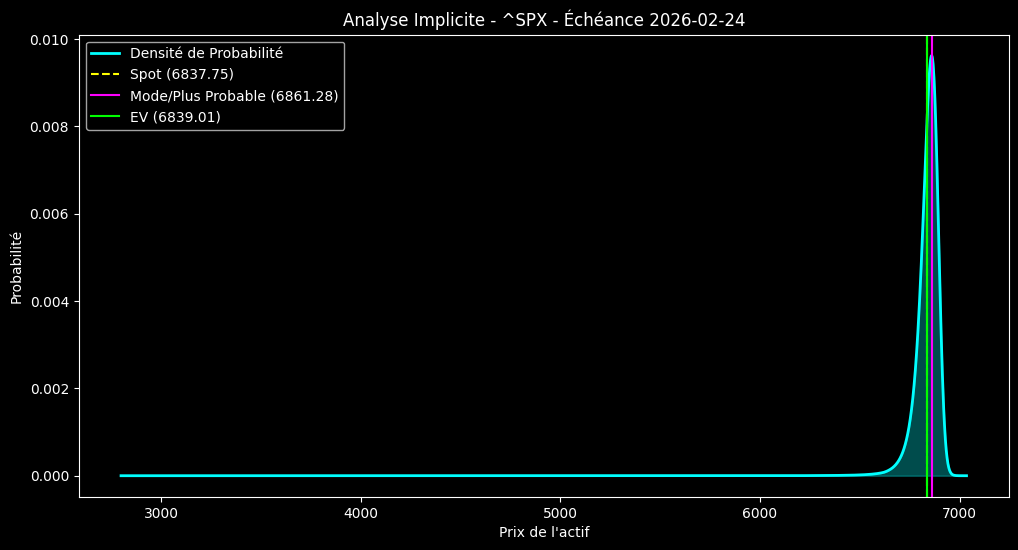

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import UnivariateSpline
from scipy.integrate import trapezoid, cumulative_trapezoid
from datetime import datetime, timedelta

class EliteQuantTerminal:
    def __init__(self, ticker, capital=10000):
        self.ticker = ticker
        self.capital = capital
        self.r = 0.045  # Taux sans risque (4.5%)

    def run_engine(self, force_date=None):
        # 1. Données Marché
        asset = yf.Ticker(self.ticker)
        history = asset.history(period="5d")
        if history.empty: return print("Erreur : Ticker ou API invalide.")
        self.S0 = history['Close'].iloc[-1]
        
        # 2. Sélection de l'échéance
        all_expiries = asset.options
        if force_date:
            # Trouve l'échéance la plus proche de la date demandée
            target = pd.to_datetime(force_date)
            target_date = min(all_expiries, key=lambda x: abs(pd.to_datetime(x) - target))
        else:
            # Par défaut : Prochaine échéance valide (pas aujourd'hui)
            today_str = datetime.now().strftime('%Y-%m-%d')
            valid_expiries = [e for e in all_expiries if e > today_str]
            target_date = valid_expiries[0] if valid_expiries else all_expiries[0]

        self.expiry_str = target_date
        print(f"Analyse de l'échéance : {self.expiry_str}")

        # 3. Récupération et Nettoyage de la chaîne d'options
        chain = asset.option_chain(target_date)
        calls = chain.calls.copy()
        calls['mid'] = (calls['bid'] + calls['ask']) / 2
        
        # Filtres de qualité (Liquidity & No-Arbitrage)
        df = calls[(calls['mid'] > 0.01) & (calls['impliedVolatility'] > 0.01)].copy()
        df = df.sort_values('strike')
        df = df[df['mid'].diff().fillna(-1) < 0] # Prix doit baisser quand strike monte

        if len(df) < 10:
            return print(f"Liquidité insuffisante pour {target_date}. Choisissez une autre date.")

        # 4. Mathématiques : PDF et CDF
        dt = (pd.to_datetime(target_date) - datetime.now()).total_seconds() / (3600*24*365)
        self.T = max(dt, 1/365)

        # Spline de Volatilité (Lissage pour éviter les pics bizarres)
        f_iv = UnivariateSpline(df['strike'], df['impliedVolatility'], s=0.01, k=3)
        
        # GRILLE DE SÉCURITÉ : On limite strictement aux strikes disponibles pour éviter l'extrapolation
        self.k_grid = np.linspace(df['strike'].min(), df['strike'].max(), 2000)
        dk = self.k_grid[1] - self.k_grid[0]

        def get_bs_price(k):
            sig = f_iv(k)
            if sig < 0.001: sig = 0.001
            d1 = (np.log(self.S0/k) + (self.r + 0.5*sig**2)*self.T) / (sig*np.sqrt(self.T))
            d2 = d1 - sig*np.sqrt(self.T)
            return self.S0 * norm.cdf(d1) - k * np.exp(-self.r * self.T) * norm.cdf(d2)

        prices = np.array([get_bs_price(k) for k in self.k_grid])
        
        # Breeden-Litzenberger (Dérivée seconde)
        pdf_raw = np.gradient(np.gradient(prices, dk), dk) * np.exp(self.r * self.T)
        self.pdf = np.maximum(pdf_raw, 0)
        self.pdf /= trapezoid(self.pdf, self.k_grid) # Normalisation
        
        self.cdf = cumulative_trapezoid(self.pdf, self.k_grid, initial=0)
        
        self.display_results()

    def display_results(self):
        # Statistiques clés
        idx_max = np.argmax(self.pdf)
        most_probable_price = self.k_grid[idx_max] # LE MODE
        expected_val = trapezoid(self.k_grid * self.pdf, self.k_grid) # L'EV
        
        idx_spot = np.argmin(np.abs(self.k_grid - self.S0))
        pop = (1 - self.cdf[idx_spot]) * 100 # Probabilité hausse
        
        print(f"\n--- RÉSULTATS {self.ticker} ---")
        print(f"Prix Actuel : {self.S0:.2f}$")
        print(f"PRIX LE PLUS PROBABLE : {most_probable_price:.2f}$")
        print(f"Objectif Mathématique (EV) : {expected_val:.2f}$")
        print(f"Probabilité de Hausse : {pop:.1f}%")

        # Visualisation
        plt.style.use('dark_background')
        plt.figure(figsize=(12, 6))
        plt.plot(self.k_grid, self.pdf, color='cyan', lw=2, label='Densité de Probabilité')
        plt.fill_between(self.k_grid, self.pdf, alpha=0.3, color='cyan')
        
        plt.axvline(self.S0, color='yellow', ls='--', label=f'Spot ({self.S0:.2f})')
        plt.axvline(most_probable_price, color='magenta', ls='-', label=f'Mode/Plus Probable ({most_probable_price:.2f})')
        plt.axvline(expected_val, color='lime', ls='-', label=f'EV ({expected_val:.2f})')
        
        plt.title(f"Analyse Implicite - {self.ticker} - Échéance {self.expiry_str}")
        plt.xlabel("Prix de l'actif")
        plt.ylabel("Probabilité")
        plt.legend()
        plt.show()

# --- EXÉCUTION ---
terminal = EliteQuantTerminal("^SPX")
terminal.run_engine(force_date="2026-02-24")